### Question
Which sensors provide the best overall evidence for engine degradation?
### Objective
Combine Result from previous analyses to rank candidate degradation sensors and provide final engineering figured for the NASA turbofan sensor analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
column_names=["engine_id","cycle"]+[f"setting_{i}" for i in range(1,4)]+[f"sensor_{i}" for i in range(1,22)]

df=pd.read_csv('../data/raw/train_FD001.txt',sep=r'\s+',header=None)

df.columns=column_names

df["max_cycle"]=df.groupby("engine_id")["cycle"].transform("max")
df["life_percent"]= (df["cycle"]/df["max_cycle"])*100

key_sensors=['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15']


In [15]:
validation_results=pd.DataFrame({'Sensor':['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15'],'Mean Within-Engine Correlation':[0.781614,-0.761514,0.810601,-0.789662,0.724844],'Percentage Engines Expected direction':[100,100,100,100,100]})

In [16]:
life_correlations=(df[key_sensors+['life_percent']].corr()['life_percent'].drop('life_percent'))

life_correlations

validation_results['Life correlations']=(validation_results["Sensor"].map(life_correlations))

In [17]:
sensor_std=df[key_sensors].std()
validation_results['Standard Deviation']=(validation_results["Sensor"].map(sensor_std))

validation_results

,Sensor,Mean Within-Engine Correlation,Percentage Engines Expected direction,Life correlations,Standard Deviation
0,sensor_4,0.781614,100,0.711539,9.000605
1,sensor_7,-0.761514,100,-0.685233,0.885092
2,sensor_11,0.810601,100,0.727496,0.267087
3,sensor_12,-0.789662,100,-0.701873,0.737553
4,sensor_15,0.724844,100,0.672931,0.037505


In [18]:
validation_results['Absolute Life Correlations']=( validation_results['Life correlations'].abs())

validation_results

,Sensor,Mean Within-Engine Correlation,Percentage Engines Expected direction,Life correlations,Standard Deviation,Absolute Life Correlations
0,sensor_4,0.781614,100,0.711539,9.000605,0.711539
1,sensor_7,-0.761514,100,-0.685233,0.885092,0.685233
2,sensor_11,0.810601,100,0.727496,0.267087,0.727496
3,sensor_12,-0.789662,100,-0.701873,0.737553,0.701873
4,sensor_15,0.724844,100,0.672931,0.037505,0.672931


In [7]:
late_life_slope_change=pd.DataFrame({'Sensor':['sensor_4','sensor_7','sensor_11','sensor_12','sensor_15'],'Late-Life Slope Change':[10.384707,-0.978514,0.314478,-0.831911,0.040718]})
late_life_slope_change

,Sensor,Late-Life Slope Change
0,sensor_4,10.384707
1,sensor_7,-0.978514
2,sensor_11,0.314478
3,sensor_12,-0.831911
4,sensor_15,0.040718


In [37]:
validation_results = validation_results.merge(late_life_slope_change)
 
validation_results['Late-Life Slope Magnitude']=(validation_results['Late-Life Slope Change'].abs())


In [38]:
validation_results.round(3)

,Sensor,Mean Within-Engine Correlation,Percentage Engines Expected direction,Life correlations,Standard Deviation,Absolute Life Correlations,Assesment,Late-Life Slope Change,Late-Life Slope Magnitude
0,sensor_11,0.811,100,0.727,0.267,0.727,,0.314,0.314
1,sensor_4,0.782,100,0.712,9.001,0.712,,10.385,10.385
2,sensor_12,-0.790,100,-0.702,0.738,0.702,,-0.832,0.832
3,sensor_7,-0.762,100,-0.685,0.885,0.685,,-0.979,0.979
4,sensor_15,0.725,100,0.673,0.038,0.673,,0.041,0.041


In [20]:
validation_results=validation_results.sort_values('Absolute Life Correlations',ascending=False)

validation_results[['Sensor','Absolute Life Correlations','Mean Within-Engine Correlation','Percentage Engines Expected direction']]

,Sensor,Absolute Life Correlations,Mean Within-Engine Correlation,Percentage Engines Expected direction
2,sensor_11,0.727496,0.810601,100
0,sensor_4,0.711539,0.781614,100
3,sensor_12,0.701873,-0.789662,100
1,sensor_7,0.685233,-0.761514,100
4,sensor_15,0.672931,0.724844,100


In [21]:
validation_results['Assesment']=''

In [23]:
normalized=df[key_sensors].copy()

for sensor in key_sensors:
    normalized[sensor]=(normalized[sensor]-normalized[sensor].mean())/normalized[sensor].std()
    
normalized['life_percent']=df['life_percent']

In [26]:
normalized['life_stage']=pd.cut(normalized['life_percent'],bins=[0,25,50,75,100],labels=['0-25%','25-50%','50-75%','75-100%'])

normalized_means=normalized.groupby('life_stage',observed=True)[key_sensors].mean()
normalized_means

,sensor_4,sensor_7,sensor_11,sensor_12,sensor_15
life_stage,,,,,
0-25%,-0.684201,0.653496,-0.698904,0.671938,-0.637379
25-50%,-0.481674,0.471800,-0.495978,0.481060,-0.465628
50-75%,-0.030076,0.027512,-0.025448,0.027577,-0.033888
75-100%,1.183159,-1.140549,1.207297,-1.167995,1.124844


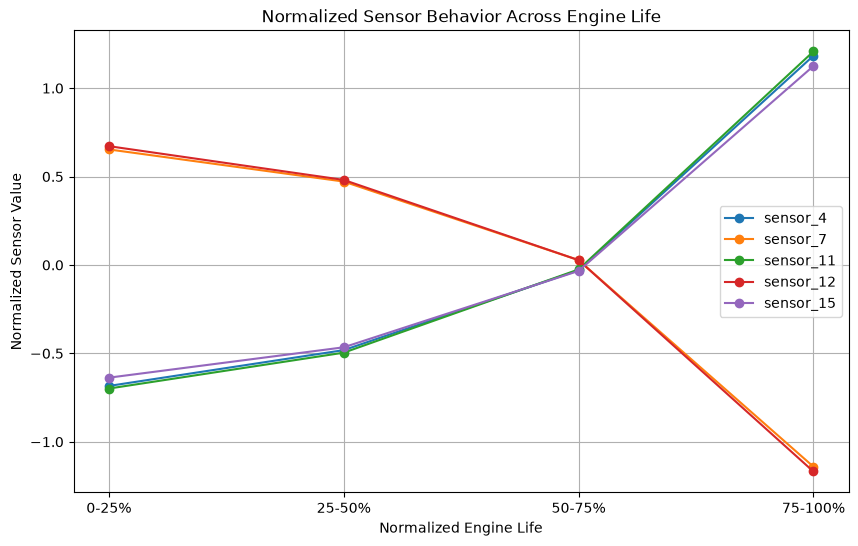

In [25]:
plt.figure(figsize=(10,6))

for sensor in key_sensors:
    plt.plot(normalized_means.index,normalized_means[sensor],marker='o',label=sensor)
    
plt.xlabel("Normalized Engine Life")
plt.ylabel("Normalized Sensor Value")
plt.title("Normalized Sensor Behavior Across Engine Life")
plt.legend()
plt.grid(True)

plt.show()

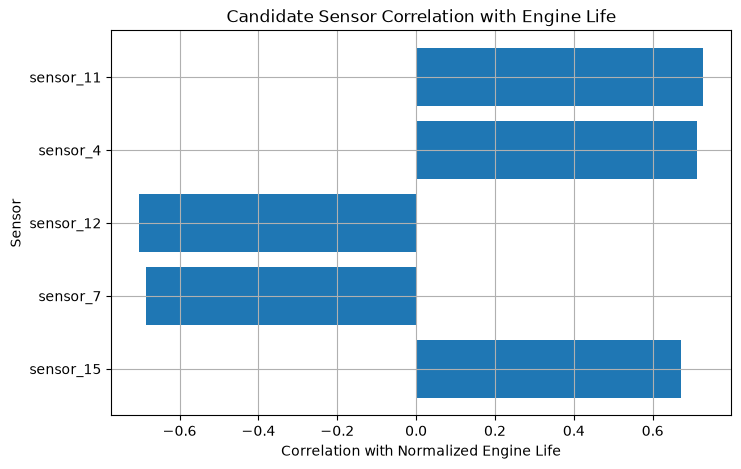

In [41]:
correlation_plot=validation_results.sort_values('Absolute Life Correlations',ascending=True)

plt.figure(figsize=(8,5))

plt.barh(correlation_plot['Sensor'],correlation_plot['Life correlations'])
plt.xlabel('Correlation with Normalized Engine Life')
plt.ylabel('Sensor')
plt.title('Candidate Sensor Correlation with Engine Life')

plt.savefig('../figures/12_Candidate Sensor Correlation with Engine Life')
plt.grid()

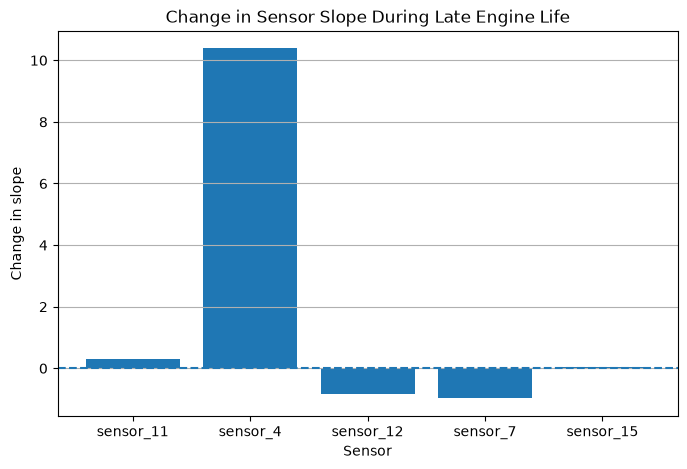

In [39]:
plt.figure(figsize=(8,5))

plt.bar(validation_results['Sensor'],validation_results['Late-Life Slope Change'])

plt.axhline(0,linestyle='--')
plt.xlabel('Sensor')
plt.ylabel('Change in slope')
plt.title('Change in Sensor Slope During Late Engine Life')
plt.grid(axis='y')

plt.show()


| Rank | Sensor | Mean Within-Engine Correlation | Expected Direction | Life Correlation | Late-Life Behavior | Assessment |
|------|--------|-------------------------------:|-------------------:|----------------:|-------------------:|------------|
| 1 | Sensor 11 | 0.811 | 100% | 0.727 | Increasing | Excellent Candidate |
| 2 | Sensor 12 | -0.790 | 100% | -0.762 | Decreasing | Excellent Candidate |
| 3 | Sensor 4 | 0.782 | 100% | 0.712 | Increasing | Excellent Candidate |
| 4 | Sensor 7 | -0.762 | 100% | -0.790 | Decreasing | Strong Candidate |
| 5 | Sensor 15 | 0.725 | 100% | 0.673 | Increasing | Good Candidate |

# Evaluation

The results from the previous analyses were combined to determine which sensors provide the strongest overall evidence of engine degradation.

Sensors 4, 7, 11, 12, and 15 demonstrated consistent relationships with normalized engine life across the dataset. All five sensors showed the expected directional behavior across the engines, with Sensors 4, 11, and 15 increasing as engine life progressed and Sensors 7 and 12 decreasing.

The late-life analysis showed that the magnitude of sensor changes generally became greater after approximately 60% normalized engine life. Sensor 4 demonstrated the largest quantified change in late-life slope, while Sensors 7 and 12 also demonstrated substantial changes. Sensors 11 and 15 exhibited smaller late-life slope changes.

The operating-condition analysis showed negligible linear correlations between the candidate sensors and the measured operating settings, suggesting that the strong sensor-life relationships are not strongly explained by these operating conditions.

Based on the combined evidence, Sensors 4, 7, 11, 12, and 15 remain the strongest candidates for monitoring engine degradation. However, the sensors should be considered degradation indicators rather than definitive failure predictors because correlation and trend analysis alone cannot establish causation or determine an exact failure threshold.
